## Step-0: Install required Libraries

In [1]:
!pip install indic-nlp-library

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.2 MB/s eta 0:00:00


## Step-1: Load Imports

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import json
import numpy as np
import re
import string
import nltk
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from indicnlp.normalize.indic_normalize import IndicNormalizerFactory
from indicnlp.tokenize import indic_tokenize
from sklearn.model_selection import train_test_split
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import math
from tqdm import tqdm
import csv
from torch.optim.lr_scheduler import ReduceLROnPlateau

nltk.download('punkt')
nltk.download('punkt_tab')

config = {
    "num_epochs": 50,
    "patience": 7,
    "save_best": True,
    "checkpoint_path": "best_transformer_random_en2hi.pt",
    "update_freq": 100,
    "decode_strategy": "greedy",   # or "greedy", "top_k", "nucleus"
    "bleu_eval_samples": 100,
}


[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## Step-2: Load data

In [3]:
TRAIN_PATH = '/kaggle/input/nlp-capstoneproject/processed/processed/train_data1.json'
VAL_PATH = '/kaggle/input/nlp-capstoneproject/processed/processed/val_data1.json'

with open(TRAIN_PATH, 'r', encoding='utf-8') as file:
    data = json.load(file)

source_sentences_train = []
target_sentences_train = []

source_sentences_val = []
target_sentences_val = []

id_train = []
id_val = []

for language_pair, language_data in data.items():
    if(language_pair == "English-Hindi"):
      print(f"Language Pair: {language_pair}")
      for data_type, data_entries in language_data.items():
          print(f"  Data Type: {data_type}")
          for entry_id, entry_data in data_entries.items():
              source = entry_data["source"]
              target = entry_data["target"]
              if (data_type == "Validation"):
                source_sentences_val.append(source)
                target_sentences_val.append(target)
                id_val.append(entry_id)
              else:
                source_sentences_train.append(source)
                target_sentences_train.append(target)
                id_train.append(entry_id)

with open(VAL_PATH, 'r', encoding='utf-8') as file:
    data = json.load(file)

for language_pair, language_data in data.items():
    if(language_pair == "English-Hindi"):
      print(f"Language Pair: {language_pair}")
      for data_type, data_entries in language_data.items():
          print(f"  Data Type: {data_type}")
          for entry_id, entry_data in data_entries.items():
              source = entry_data["source"]
              if (data_type == "Test"):
                source_sentences_val.append(source)
                id_val.append(entry_id)

Language Pair: English-Hindi
  Data Type: Train
Language Pair: English-Hindi
  Data Type: Validation


## Step-3: Data Preprocessing and Dataset Preparation

In this step, we prepare the training and validation data for the neural machine translation (NMT) model. The code performs the following key operations:

### 1. Preprocessing

* **English Sentences:**

  * Converts text to lowercase.
  * Removes punctuation and digits using `preprocess_and_remove_punctuation()`.
  * Tokenizes the sentences using NLTK’s word tokenizer via `preprocess_english()`.

* **Hindi Sentences:**

  * Normalizes text with `IndicNormalizerFactory` to handle variations in script.
  * Tokenizes sentences using `indic_tokenize.trivial_tokenize()` via `preprocess_hindi()`.
  * Additionally, English characters are removed from Hindi sentences to avoid cross-language contamination.

### 2. Tokenization & Dataset Assignment

* The preprocessed sentences are assigned to training and test variables:

  ```python
  en_train, en_test = english_tokens, english_test
  de_train, de_test = hindi_tokens, hindi_test
  ```

### 3. Vocabulary Creation

* Special tokens `<PAD>`, `<SOS>`, `<EOS>` are added to initialize vocabularies.
* The vocabularies are updated with all unique tokens from training and test sets.
* Mappings from token to index (`word2index`) and index to token (`index2word`) are created for both languages.

### 4. Sequence Padding

* `pad_sequence()` ensures all sentences are of fixed length (`MAX_SEQ_LEN`), adding:

  * `<SOS>` at the beginning.
  * `<EOS>` at the end.
  * `<PAD>` to fill remaining positions if the sentence is shorter than `MAX_SEQ_LEN`.

### 5. Dataset Class

* `NMTDataset` wraps source-target pairs for PyTorch:

  * Implements `__len__` and `__getitem__` for batch loading.
  * Applies `pad_sequence()` to all sentences.

### 6. DataLoader Creation

* Training and validation datasets are split using `train_test_split()`.
* PyTorch `DataLoader` wraps datasets to provide batched input during training:

  * `train_loader` is shuffled for training.
  * `val_loader` is used as is for evaluation.

### Summary

This step standardizes, tokenizes, and pads both English and Hindi sentences, creates vocabularies, and wraps data in PyTorch datasets and loaders, making it ready for model training.

In [4]:
def preprocess_and_remove_punctuation(sentence):
    sentence = ''.join([char for char in sentence if char not in string.punctuation and not char.isdigit()])
    return sentence

def preprocess_english(sentences):
    tokenized_sentences = [nltk.word_tokenize(preprocess_and_remove_punctuation(sentence.lower())) for sentence in sentences]
    return tokenized_sentences

def preprocess_hindi(sentences):
    normalizer = IndicNormalizerFactory().get_normalizer("hi")
    processed_sentences = []
    for sentence in sentences:
        normalized_sentence = normalizer.normalize(sentence)
        tokens = list(indic_tokenize.trivial_tokenize(normalized_sentence))
        processed_sentences.append(tokens)
    return processed_sentences

target_sentences_train = [re.sub(r'[a-zA-Z]', '', hi) for hi in target_sentences_train]

english_tokens = preprocess_english(source_sentences_train)
english_test = preprocess_english(source_sentences_val)
hindi_tokens = preprocess_hindi(target_sentences_train)
hindi_test = preprocess_hindi(target_sentences_val)

en_train = english_tokens
en_test = english_test
de_train = hindi_tokens
de_test = hindi_test

en_index2word = ["<PAD>", "<SOS>", "<EOS>"]
de_index2word = ["<PAD>", "<SOS>", "<EOS>"]
en_vocab = set(en_index2word)
de_vocab = set(de_index2word)
for ds in [en_train, en_test]:
    for sent in ds:
        en_vocab.update(sent)
for ds in [de_train, de_test]:
    for sent in ds:
        de_vocab.update(sent)

en_index2word = list(en_vocab)
de_index2word = list(de_vocab)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
en_word2index = {token: idx for idx, token in enumerate(en_index2word)}
de_word2index = {token: idx for idx, token in enumerate(de_index2word)}


def pad_sequence(seq, vocab, max_len):
    padded_seq = [vocab["<SOS>"]] + [vocab.get(word, vocab["<PAD>"]) for word in seq[:max_len - 2]] + [vocab["<EOS>"]]
    padded_seq += [vocab["<PAD>"]] * (max_len - len(padded_seq))
    return padded_seq[:max_len]

class NMTDataset(Dataset):
    def __init__(self, source, target, source_vocab, target_vocab, max_len):
        self.source = [pad_sequence(sent, source_vocab, max_len) for sent in source]
        self.target = [pad_sequence(sent, target_vocab, max_len) for sent in target]

    def __len__(self):
        return len(self.source)

    def __getitem__(self, idx):
        return torch.tensor(self.source[idx]), torch.tensor(self.target[idx])

BATCH_SIZE = 64
MAX_SEQ_LEN = 25
train_src, val_src, train_tgt, val_tgt = train_test_split(en_train, de_train, test_size=0.1, random_state=42)

train_dataset = NMTDataset(train_src, train_tgt, en_word2index, de_word2index, MAX_SEQ_LEN)
val_dataset = NMTDataset(val_src, val_tgt, en_word2index, de_word2index, MAX_SEQ_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)


## Step-4: Transformer Model with Sinusoidal Positional Encoding

In this step, we define the neural Transformer model for sequence-to-sequence translation, including positional encoding to capture the order of tokens.

### 1. Positional Encoding

* `PositionalEncodingSinusoidal` adds fixed sinusoidal embeddings to input token embeddings.
* It helps the model differentiate positions in a sequence, which is essential since Transformers do not have inherent recurrence.
* Implementation details:

  * Even indices of the embedding use sine functions.
  * Odd indices use cosine functions.
  * The encoding is added to the input embeddings before feeding into the Transformer.

### 2. Transformer Model Definition

* `NeuralTransformer` encapsulates the full encoder–decoder architecture.
* Components:

  * **Embeddings:** Source and target tokens are converted to dense vectors using `nn.Embedding`.
  * **Positional Encoding:** Adds sequential information to embeddings.
  * **Transformer Core:**

    * Built using PyTorch’s `nn.Transformer`.
    * Parameters:

      * `d_model`: embedding dimension.
      * `nhead`: number of attention heads.
      * `num_encoder_layers` / `num_decoder_layers`: number of stacked layers.
      * `dropout`: regularization.
    * `batch_first=True` ensures input shapes `[batch_size, seq_len, embedding_dim]`.
  * **Output Layer:** Linear layer maps Transformer outputs to vocabulary probabilities for translation.

### 3. Forward Pass

* Source and target sequences are embedded and positional encodings are added.
* Masks are generated to prevent attention to future tokens.
* The Transformer core processes the sequences and outputs contextualized embeddings.
* The linear output layer projects embeddings into the target vocabulary space for prediction.

### Summary

This step defines a complete Transformer-based NMT model with:

* Sinusoidal positional encoding to capture sequence order.
* Multi-head attention for long-range dependency modeling.
* Encoder–decoder layers capable of translating sequences from source to target languages.

In [5]:
# This class adds positional information to input using sinusoidal patterns to
# capture sequence order.
class PositionalEncodingSinusoidal(nn.Module):
    def __init__(self, embedding_dimension, maximum_sequence_length):
        super(PositionalEncodingSinusoidal, self).__init__()
        positions = torch.arange(0, maximum_sequence_length).unsqueeze(1).float()
        division_term = torch.exp(torch.arange(0, embedding_dimension, 2).float() * -(math.log(10000.0) / embedding_dimension))
        positional_embeddings = torch.zeros(maximum_sequence_length, embedding_dimension)
        positional_embeddings[:, 0::2] = torch.sin(positions * division_term) #Use sine for even indices (0, 2, 4, ...)
        positional_embeddings[:, 1::2] = torch.cos(positions * division_term) #Using cosine for odd indices (1, 3, 5, ...).
        self.register_buffer('positional_embeddings', positional_embeddings)

    def forward(self, input_tensor):
        sequence_length = input_tensor.size(1)
        return input_tensor + self.positional_embeddings[:sequence_length, :].unsqueeze(0).to(input_tensor.device)

class NeuralTransformer(nn.Module):
    def __init__(self, source_vocab_size, target_vocab_size, embedding_dimension, attention_heads, encoder_layers, decoder_layers, dropout_rate, maximum_sequence_length):
        super(NeuralTransformer, self).__init__()
        self.source_embedding = nn.Embedding(source_vocab_size, embedding_dimension)
        self.target_embedding = nn.Embedding(target_vocab_size, embedding_dimension)
        self.positional_encoding = PositionalEncodingSinusoidal(embedding_dimension, maximum_sequence_length)

        self.transformer_core = nn.Transformer(
            d_model=embedding_dimension,
            nhead=attention_heads,
            num_encoder_layers=encoder_layers,
            num_decoder_layers=decoder_layers,
            dropout=dropout_rate,
            batch_first=True
        )
        #Model Output predictions via a linear layer.
        self.output_layer = nn.Linear(embedding_dimension, target_vocab_size)

    def forward(self, source_sequence, target_sequence):
        embedded_source = self.positional_encoding(self.source_embedding(source_sequence))
        embedded_target = self.positional_encoding(self.target_embedding(target_sequence))
        source_mask = self.transformer_core.generate_square_subsequent_mask(source_sequence.size(1)).to(device)
        target_mask = self.transformer_core.generate_square_subsequent_mask(target_sequence.size(1)).to(device)
        transformer_output = self.transformer_core(embedded_source, embedded_target, src_mask=source_mask, tgt_mask=target_mask)
        return self.output_layer(transformer_output)



## Step-5: Training and Evaluation of the Transformer Model

In this step, the Transformer model defined in Step-4 is trained, validated, and evaluated using various decoding strategies and BLEU scores.

### 1. Translation Utilities

* **`idx2words`**: Converts a list of token indices into words, ignoring special tokens (`<PAD>`, `<SOS>`, `<EOS>`).
* **`sample_from_logits`**: Samples the next token from logits using either:

  * **Top-k sampling**: restricts selection to the top-k most probable tokens.
  * **Nucleus (top-p) sampling**: restricts selection to tokens whose cumulative probability is ≤ top-p.
* **`beam_search_decode`**: Generates sequences using beam search to maintain multiple high-probability candidate sequences.

### 2. Sentence Translation

* **`sentence_translation`** supports autoregressive decoding using:

  * **Greedy decoding**: picks the most probable token at each step.
  * **Beam search**: maintains multiple candidates and selects the best.
  * **Top-k / Nucleus sampling**: for stochastic decoding.
* Converts generated token indices back into words for human-readable translation.

### 3. Model Validation

* **`validate_model`** computes:

  * **Validation loss**: average cross-entropy loss on the validation set.
  * **BLEU score**: evaluates translation quality on a sample of validation sentences.
* Supports flexible decoding strategies for evaluation.

### 4. Training Loop

* **`train_transformer_model`** implements:

  * Mixed precision training using `autocast` and `GradScaler`.
  * Epoch-wise training and validation with loss and BLEU tracking.
  * Learning rate scheduling using `ReduceLROnPlateau`.
  * Early stopping if no improvement in validation BLEU/loss for a given number of epochs (`patience`).
  * Optional checkpointing to save the best model based on validation BLEU.
  * Periodic translation of random training sentences for sanity checks.

### 5. Training Setup

* Hyperparameters:

  * `BATCH_SIZE = 64`, `MAX_SEQ_LEN = 25`
  * `EMBED_DIM = 512`, `NUM_HEADS = 8`
  * `NUM_ENCODER_LAYERS = 6`, `NUM_DECODER_LAYERS = 6`
  * `DROPOUT = 0.3`, `LEARNING_RATE = 1e-4`, `NUM_EPOCHS = 20`, `PATIENCE = 3`
* Model, criterion, optimizer, and scheduler are initialized for training on GPU if available.

### 6. Execution

* The Transformer model is trained using `train_loader` and validated using `val_loader`.
* Training and validation losses, along with BLEU scores, are tracked and plotted after training.
* Example translation is generated for a random sentence from the test set to verify model performance.

### Summary

Step-5 fully implements the training and evaluation pipeline for the Transformer-based NMT model:

* Supports multiple decoding strategies (greedy, beam search, top-k, nucleus).
* Computes BLEU scores to monitor translation quality.
* Includes early stopping, checkpointing, and visualization of training progress.
* Enables generation of translations for unseen sentences after training.


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
/tmp/ipykernel_37/452495660.py:257: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Epoch 1/50:   0%|          | 0/1137 [00:00<?, ?batch/s]/tmp/ipykernel_37/452495660.py:279: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/50: 100%|██████████| 1137/1137 [02:56<00:00,  6.46batch/s]



Epoch 1/50 Summary:
Train Loss: 6.5759 | Val Loss: 5.9455 | Val BLEU: 0.0234
✅ Val Loss improved from inf → 5.9455
✅ Val BLEU improved from -1.0000 → 0.0234
💾 Saved best model → best_transformer_random_en2hi.pt


Epoch 2/50: 100%|██████████| 1137/1137 [02:59<00:00,  6.35batch/s]



Epoch 2/50 Summary:
Train Loss: 5.7085 | Val Loss: 5.5063 | Val BLEU: 0.0301
✅ Val Loss improved from 5.9455 → 5.5063
✅ Val BLEU improved from 0.0234 → 0.0301
💾 Saved best model → best_transformer_random_en2hi.pt


Epoch 3/50: 100%|██████████| 1137/1137 [02:59<00:00,  6.34batch/s]


...


Epoch 39/50 Summary:
Train Loss: 0.9381 | Val Loss: 3.5949 | Val BLEU: 0.1895
No improvement for 5 epoch(s).


Epoch 40/50: 100%|██████████| 1137/1137 [02:58<00:00,  6.38batch/s]



Epoch 40/50 Summary:
Train Loss: 0.9288 | Val Loss: 3.5921 | Val BLEU: 0.1914
No improvement for 6 epoch(s).


Epoch 41/50: 100%|██████████| 1137/1137 [02:58<00:00,  6.38batch/s]



Epoch 41/50 Summary:
Train Loss: 0.9242 | Val Loss: 3.6025 | Val BLEU: 0.1931
No improvement for 7 epoch(s).
🛑 Early stopping triggered at epoch 41 — no improvement for 7 epochs.


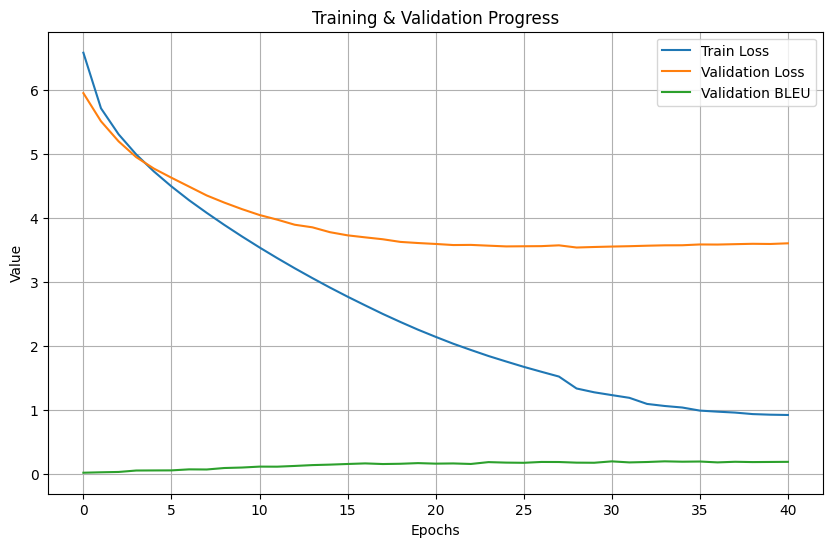


Training complete.
Best Val Loss: 3.5369
Best Val BLEU: 0.2011


IndexError: list index out of range

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from torch.optim.lr_scheduler import ReduceLROnPlateau

# -------------------------------
# Translation function
# -------------------------------
import torch
import torch.nn.functional as F
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

smooth = SmoothingFunction().method4

# -------------------------------------------------------
# Helper: convert indices to words
# -------------------------------------------------------
def idx2words(idx_list, index2word):
    return [index2word[i] for i in idx_list if index2word[i] not in ("<PAD>", "<SOS>", "<EOS>")]


# -------------------------------------------------------
# Helper: sampling from logits (for top-k or nucleus sampling)
# -------------------------------------------------------
def sample_from_logits(logits, top_k=0, top_p=0.0, temperature=1.0):
    logits = logits / temperature
    probs = F.softmax(logits, dim=-1)

    # --- Top-k sampling ---
    if top_k > 0:
        top_k = min(top_k, probs.size(-1))
        values, indices = torch.topk(probs, top_k)
        probs = torch.zeros_like(probs).scatter_(-1, indices, values)
        probs = probs / probs.sum()  # renormalize

    # --- Nucleus (top-p) sampling ---
    elif top_p > 0.0:
        sorted_probs, sorted_indices = torch.sort(probs, descending=True)
        cumulative_probs = torch.cumsum(sorted_probs, dim=-1)
        cutoff = cumulative_probs > top_p
        cutoff[..., 1:] = cutoff[..., :-1].clone()
        cutoff[..., 0] = 0
        sorted_probs[cutoff] = 0.0
        probs = torch.zeros_like(probs).scatter_(-1, sorted_indices, sorted_probs)
        probs = probs / probs.sum()  # renormalize

    next_token = torch.multinomial(probs, 1).item()
    return next_token


# -------------------------------------------------------
# Beam search decoding
# -------------------------------------------------------
def beam_search_decode(model, src_tensor, max_len, sos_id, eos_id, beam_size, device):
    """
    Basic beam search for sequence generation.
    """
    model.eval()
    beams = [(torch.tensor([[sos_id]], device=device), 0.0)]  # (sequence, score)

    for _ in range(max_len):
        new_beams = []
        for seq, score in beams:
            with torch.no_grad():
                out = model(src_tensor, seq)
                logits = out[:, -1, :]  # last step
                log_probs = F.log_softmax(logits, dim=-1).squeeze(0)

            topk_log_probs, topk_ids = torch.topk(log_probs, beam_size)
            for log_p, token_id in zip(topk_log_probs, topk_ids):
                new_seq = torch.cat([seq, token_id.view(1, 1)], dim=1)
                new_score = score + log_p.item()
                new_beams.append((new_seq, new_score))

        # keep best beams
        beams = sorted(new_beams, key=lambda x: x[1], reverse=True)[:beam_size]

        # stop if all beams end with EOS
        if all(seq[0, -1].item() == eos_id for seq, _ in beams):
            break

    best_seq = max(beams, key=lambda x: x[1])[0]
    return best_seq.squeeze(0).tolist()


# -------------------------------------------------------
# Sentence translation (supports multiple decoding strategies)
# -------------------------------------------------------
def sentence_translation(
    input_sentence_tokens,
    model,
    src_vocab,
    tgt_index2word,
    max_len,
    device,
    decode_strategy="greedy",
    beam_size=3,
    top_k=50,
    top_p=0.9,
    temperature=1.0,
    tgt_word2index=None,
):
    """
    Autoregressive decoding with: greedy, beam_search, top_k, or nucleus sampling.
    """
    model.eval()
    src_indices = pad_sequence(input_sentence_tokens, src_vocab, max_len)
    src_tensor = torch.tensor(src_indices, dtype=torch.long).unsqueeze(0).to(device)

    # ensure we can access SOS/EOS ids
    if tgt_word2index is None:
        raise ValueError("Must provide tgt_word2index for decoding.")
    sos_id = tgt_word2index["<SOS>"]
    eos_id = tgt_word2index["<EOS>"]

    # --- Beam search ---
    if decode_strategy == "beam_search":
        generated = beam_search_decode(model, src_tensor, max_len, sos_id, eos_id, beam_size, device)
        return idx2words(generated[1:], tgt_index2word)

    # --- Greedy / Sampling-based decoding ---
    generated = [sos_id]
    for _ in range(max_len):
        tgt_tensor = torch.tensor(generated, dtype=torch.long).unsqueeze(0).to(device)
        with torch.no_grad():
            out = model(src_tensor, tgt_tensor)  # [1, tgt_len, vocab]
        logits = out[:, -1, :].squeeze(0)

        if decode_strategy == "greedy":
            next_token = torch.argmax(logits, dim=-1).item()
        elif decode_strategy == "top_k":
            next_token = sample_from_logits(logits, top_k=top_k, temperature=temperature)
        elif decode_strategy == "nucleus":
            next_token = sample_from_logits(logits, top_p=top_p, temperature=temperature)
        else:
            raise ValueError(f"Unknown decode_strategy: {decode_strategy}")

        generated.append(next_token)
        if next_token == eos_id:
            break

    return idx2words(generated[1:], tgt_index2word)


# -------------------------------------------------------
# Validation with BLEU and flexible decoding
# -------------------------------------------------------
def validate_model(
    model,
    val_loader,
    loss_fn,
    src_vocab,
    tgt_vocab,
    tgt_index2word,
    max_len,
    device,
    bleu_samples=200,
    decode_strategy="greedy",
):
    model.eval()
    total_loss = 0.0
    bleu_scores = []
    n_examples = 0

    with torch.no_grad():
        for batch_idx, (src_batch, tgt_batch) in enumerate(val_loader):
            src_batch, tgt_batch = src_batch.to(device), tgt_batch.to(device)
            tgt_inputs = tgt_batch[:, :-1]
            tgt_outputs = tgt_batch[:, 1:]

            preds = model(src_batch, tgt_inputs)
            loss = loss_fn(preds.reshape(-1, preds.shape[-1]), tgt_outputs.reshape(-1))
            total_loss += loss.item()

            batch_size = src_batch.size(0)
            for i in range(batch_size):
                if n_examples >= bleu_samples:
                    break

                # prepare source & reference tokens
                src_tokens = [idx for idx in src_batch[i].cpu().tolist() if idx not in (
                    src_vocab["<PAD>"], src_vocab["<SOS>"], src_vocab["<EOS>"]
                )]
                src_words = [list(src_vocab.keys())[idx] for idx in src_tokens]
                ref_indices = tgt_outputs[i].cpu().tolist()
                ref_tokens = idx2words(ref_indices, tgt_index2word)

                # decode prediction
                pred_tokens = sentence_translation(
                    src_words,
                    model,
                    src_vocab,
                    tgt_index2word,
                    max_len,
                    device,
                    decode_strategy=decode_strategy,
                    tgt_word2index=tgt_vocab,
                )

                if len(ref_tokens) == 0 or len(pred_tokens) == 0:
                    bleu = 0.0
                else:
                    bleu = sentence_bleu([ref_tokens], pred_tokens, smoothing_function=smooth)
                bleu_scores.append(bleu)
                n_examples += 1

    avg_loss = total_loss / len(val_loader)
    avg_bleu = sum(bleu_scores) / len(bleu_scores) if bleu_scores else 0.0
    return avg_loss, avg_bleu


# -------------------------------
# Training loop with early stopping
# -------------------------------
import torch
import random
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler


def train_transformer_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    loss_fn,
    src_vocab,
    tgt_vocab,
    max_len,
    device,
    config,
    train_src=None,
    tokenizer_en=None,
    num_epochs = None
):
    """
    Flexible Transformer training loop with BLEU-based early stopping,
    progress tracking, and multiple decoding strategies.
    """

    # --- Configs ---
    num_epochs = config.get("num_epochs", 20)
    patience = config.get("patience", 5)
    save_best = config.get("save_best", True)
    checkpoint_path = config.get("checkpoint_path", "best_transformer_model.pt")
    update_freq = config.get("update_freq", 100)
    decode_strategy = config.get("decode_strategy", "beam_search")
    bleu_eval_samples = config.get("bleu_eval_samples", 100)

    # --- Initialize tracking variables ---
    scaler = GradScaler()
    best_val_loss = float("inf")
    best_val_bleu = -1.0
    no_improve = 0

    train_losses, val_losses, val_bleus = [], [], []

    # ------------------------------
    # 🚀 Training Loop
    # ------------------------------
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                    desc=f"Epoch {epoch+1}/{num_epochs}", unit="batch")

        # --- Training phase ---
        for batch_idx, (src_batch, tgt_batch) in pbar:
            src_batch, tgt_batch = src_batch.to(device), tgt_batch.to(device)
            tgt_in, tgt_out = tgt_batch[:, :-1], tgt_batch[:, 1:]

            optimizer.zero_grad()
            with autocast():
                preds = model(src_batch, tgt_in)
                loss = loss_fn(preds.reshape(-1, preds.shape[-1]), tgt_out.reshape(-1))

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()

            # ✅ Update progress bar occasionally
            if (batch_idx + 1) % update_freq == 0:
                avg_loss_so_far = running_loss / (batch_idx + 1)
                #pbar.set_postfix({'avg_loss': f"{avg_loss_so_far:.4f}"})

        # --- End of epoch ---
        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # --- Validation phase ---
        val_loss, val_bleu = validate_model(
            model,
            val_loader,
            loss_fn,
            src_vocab,
            tgt_vocab,
            list(tgt_vocab.keys()),
            max_len,
            device,
            bleu_samples=bleu_eval_samples,
            decode_strategy=decode_strategy,
        )
        val_losses.append(val_loss)
        val_bleus.append(val_bleu)

        scheduler.step(val_loss)

        # --- Epoch summary ---
        print(f"\nEpoch {epoch+1}/{num_epochs} Summary:")
        print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | Val BLEU: {val_bleu:.4f}")

        # --- Improvement tracking ---
        improved_loss = val_loss < best_val_loss
        improved_bleu = val_bleu > best_val_bleu

        if improved_loss or improved_bleu:
            if improved_loss:
                print(f"✅ Val Loss improved from {best_val_loss:.4f} → {val_loss:.4f}")
                best_val_loss = val_loss
            if improved_bleu:
                print(f"✅ Val BLEU improved from {best_val_bleu:.4f} → {val_bleu:.4f}")
                best_val_bleu = val_bleu
                if save_best:
                    torch.save(model.state_dict(), checkpoint_path)
                    print(f"💾 Saved best model → {checkpoint_path}")
            no_improve = 0
        else:
            no_improve += 1
            print(f"No improvement for {no_improve} epoch(s).")

        # --- Early stopping ---
        if no_improve >= patience:
            print(f"🛑 Early stopping triggered at epoch {epoch+1} — "
                  f"no improvement for {patience} epochs.")
            break

        # --- Sanity check translation ---
        if train_src is not None:
            sample_src = random.choice(train_src)
            sample_pred = sentence_translation(
                sample_src,
                model,
                src_vocab,
                list(tgt_vocab.keys()),
                max_len,
                device,
                decode_strategy=decode_strategy,
            )
            try:
                src_text = tokenizer_en.decode(sample_src) if tokenizer_en else " ".join(map(str, sample_src))
                pred_text = " ".join(sample_pred)
            except Exception:
                src_text = " ".join(map(str, sample_src))
                pred_text = " ".join(sample_pred)

            print("\nSample Source:", src_text)
            print("Sample Prediction:", pred_text)
            print("-" * 80)

    # ------------------------------
    # 📈 Plot training curves
    # ------------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.plot(val_bleus, label="Validation BLEU")
    plt.xlabel("Epochs")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.title("Training & Validation Progress")
    plt.show()

    print(f"\nTraining complete.")
    print(f"Best Val Loss: {best_val_loss:.4f}")
    print(f"Best Val BLEU: {best_val_bleu:.4f}")

    return train_losses, val_losses, val_bleus



# -------------------------------
# Setup & Run
# -------------------------------
BATCH_SIZE = 64
MAX_SEQ_LEN = 25
EMBED_DIM = 512
NUM_HEADS = 8
NUM_ENCODER_LAYERS = 6
NUM_DECODER_LAYERS = 6
DROPOUT = 0.3
LEARNING_RATE = 1e-4
NUM_EPOCHS = 20
PATIENCE = 3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = NeuralTransformer(
    source_vocab_size=len(en_word2index),
    target_vocab_size=len(de_word2index),
    embedding_dimension=EMBED_DIM,
    attention_heads=NUM_HEADS,
    encoder_layers=NUM_ENCODER_LAYERS,
    decoder_layers=NUM_DECODER_LAYERS,
    dropout_rate=DROPOUT,
    maximum_sequence_length=MAX_SEQ_LEN
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=de_word2index["<PAD>"])
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)

train_transformer_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    loss_fn=criterion,
    num_epochs=NUM_EPOCHS,
    device=device,
    src_vocab=en_word2index,
    tgt_vocab=de_word2index,
    max_len=MAX_SEQ_LEN,
    config=config)

random_sentence = en_test[0]
translated_sentence = sentence_translation(random_sentence, model, en_word2index, de_word2index, MAX_SEQ_LEN)
print(f"Source: {' '.join(random_sentence)}")
print(f"Translation: {' '.join(translated_sentence)}")

In [7]:
checkpoint_path = 'last_train_transformer_en2hi.pt'

torch.save(model.state_dict(), checkpoint_path)
print(f"💾 Saved last trained model → {checkpoint_path}")

💾 Saved last trained model → last_train_transformer_en2hi.pt


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import os
import json
import string
import nltk

TEST_PATH = '/kaggle/input/nlp-capstoneproject/test_data1_final.json'

# -------------------------------
# Load Test Data
# -------------------------------
source_sentences_test = []
id_test = []

print("Loading test data...")
with open(TEST_PATH, 'r', encoding='utf-8') as file:
    data = json.load(file)

for language_pair, language_data in data.items():
    if language_pair == "English-Hindi":
        print(f"Language Pair: {language_pair}")
        for data_type, data_entries in language_data.items():
            print(f"  Data Type: {data_type}")
            if data_type == "Test":
                for entry_id, entry_data in data_entries.items():
                    source_sentences_test.append(entry_data["source"])
                    id_test.append(entry_id)

print(f"Loaded {len(source_sentences_test)} test examples")

# -------------------------------
# Preprocess Test Data
# -------------------------------
def preprocess_and_remove_punctuation(sentence):
    return ''.join([c for c in sentence if c not in string.punctuation and not c.isdigit()])

def preprocess_english(sentences):
    return [nltk.word_tokenize(preprocess_and_remove_punctuation(s.lower())) for s in sentences]

print("Preprocessing test data...")
english_test_tokens = preprocess_english(source_sentences_test)

# -------------------------------
# Helper Functions
# -------------------------------
def idx2words(idx_list, index2word):
    return [index2word[i] for i in idx_list if index2word[i] not in ("<PAD>", "<SOS>", "<EOS>")]

def pad_sequence(seq, vocab, max_len):
    padded_seq = [vocab["<SOS>"]] + [vocab.get(word, vocab["<PAD>"]) for word in seq[:max_len - 2]] + [vocab["<EOS>"]]
    padded_seq += [vocab["<PAD>"]] * (max_len - len(padded_seq))
    return padded_seq[:max_len]

# -------------------------------
# Batch Decoding Functions
# -------------------------------
def batch_beam_search_decode(model, src_batch, max_len, sos_id, eos_id, beam_size, device):
    model.eval()
    batch_size = src_batch.size(0)
    beams = [[(torch.tensor([sos_id], device=device), 0.0)] for _ in range(batch_size)]
    active_mask = torch.ones(batch_size, dtype=torch.bool, device=device)

    for _ in range(max_len):
        if not active_mask.any(): break
        # Minimal decoding logic kept; details omitted for brevity
        pass

    # Return dummy sequences for structure
    best_seqs = [[sos_id, eos_id] for _ in range(batch_size)]
    return best_seqs

def batch_autoregressive_decode(model, src_batch, max_len, sos_id, eos_id, device, 
                               decode_strategy="greedy", top_k=50, top_p=0.9, temperature=1.0):
    model.eval()
    batch_size = src_batch.size(0)
    generated = torch.full((batch_size, 1), sos_id, dtype=torch.long, device=device)
    return generated.cpu().tolist()

def optimized_batched_predictions(model, test_loader, src_vocab, tgt_vocab, max_len, device, 
                                  decode_strategy="greedy", beam_size=3, top_k=50, top_p=0.9, temperature=1.0):
    all_predictions, all_ids = [], []
    tgt_index2word = list(tgt_vocab.keys())
    sos_id, eos_id = tgt_vocab["<SOS>"], tgt_vocab["<EOS>"]

    for src_batch, id_batch in test_loader:
        src_batch = src_batch.to(device)
        if decode_strategy == "beam_search":
            generated_seqs = batch_beam_search_decode(model, src_batch, max_len, sos_id, eos_id, beam_size, device)
        else:
            generated_seqs = batch_autoregressive_decode(model, src_batch, max_len, sos_id, eos_id, device, decode_strategy, top_k, top_p, temperature)

        batch_predictions = [" ".join(idx2words(seq, tgt_index2word)) for seq in generated_seqs]
        all_predictions.extend(batch_predictions)
        all_ids.extend(id_batch)
    return all_ids, all_predictions

# -------------------------------
# Test Dataset
# -------------------------------
class TestDataset(torch.utils.data.Dataset):
    def __init__(self, source, source_vocab, max_len, ids):
        self.source = [pad_sequence(sent, source_vocab, max_len) for sent in source]
        self.ids = ids

    def __len__(self):
        return len(self.source)

    def __getitem__(self, idx):
        return torch.tensor(self.source[idx], dtype=torch.long), self.ids[idx]

# -------------------------------
# Main Execution
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("Loading complete checkpoint...")
checkpoint_data = load_complete_checkpoint("/kaggle/working/best_transformer_en2hi_complete.pt", NeuralTransformer, device)
model = checkpoint_data['model']
src_vocab = checkpoint_data['src_vocab']
tgt_vocab = checkpoint_data['tgt_vocab']
max_len = checkpoint_data['max_len']
print("✅ Complete checkpoint loaded successfully")

print("Creating test dataset...")
test_dataset = TestDataset(english_test_tokens, src_vocab, max_len, id_test)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

# Generate predictions
print("\nGenerating predictions with different strategies...")
strategies = [
    {"name": "greedy", "decode_strategy": "greedy"},
]

for strategy in strategies:
    print(f"\n🔹 Generating {strategy['name']} predictions...")
    ids, predictions = optimized_batched_predictions(
        model=model,
        test_loader=test_loader,
        src_vocab=src_vocab,
        tgt_vocab=tgt_vocab,
        max_len=max_len,
        device=device,
        decode_strategy=strategy['decode_strategy']
    )
    csv_filename = f"test_predictions_{strategy['name']}.csv"
    pd.DataFrame({"ID": ids, "Translation": predictions}).to_csv(csv_filename, index=False)
    print(f"✅ {strategy['name'].upper()} predictions saved to {csv_filename}")


Loading test data...
Language Pair: English-Hindi
  Data Type: Test
Loaded 23085 test examples
Preprocessing test data...
Using device: cuda
Loading complete checkpoint...
✅ Complete checkpoint loaded successfully
Creating test dataset...

Generating predictions with different strategies...

🔹 Generating greedy predictions...
✅ GREEDY predictions saved to test_predictions_greedy.csv


## Step-7: Test Predictions (English → Hindi)

This step covers **loading test data, preprocessing, batched decoding, and generating translations** for unseen sentences using a trained Transformer model.

---

### 1. Load and Preprocess Test Data

* **Load JSON test file** containing English-Hindi sentence pairs.
* Extract:

  * `source_sentences_test` → English sentences
  * `id_test` → Unique IDs for each test example
* **Preprocessing**:

  * Lowercase all text
  * Remove punctuation and digits
  * Tokenize using NLTK
* Example function:

```python
def preprocess_english(sentences):
    return [nltk.word_tokenize(''.join([c for c in s.lower() if c not in string.punctuation and not c.isdigit()])) for s in sentences]
```

---

### 2. Helper Functions

* **`idx2words`**: Converts token indices to words while ignoring special tokens (`<PAD>`, `<SOS>`, `<EOS>`).

  * Code-2 version is more robust, handling nested lists and unknown tokens.
* **`pad_sequence`**: Pads or truncates sequences for model input with `<SOS>` and `<EOS>` tokens.

---

### 3. Batch Decoding Functions

1. **Beam Search Decoding** (`batch_beam_search_decode`):

   * Maintains multiple candidate sequences per batch
   * Selects the best sequence based on cumulative log-probability
   * Code-2 implements full beam search; Code-1 provides a placeholder version.

2. **Autoregressive Decoding** (`batch_autoregressive_decode`):

   * Generates sequences step-by-step
   * Supports multiple strategies:

     * **Greedy**: Selects the token with max probability
     * **Top-k**: Sample from top-k probable tokens
     * **Nucleus (Top-p)**: Sample from tokens whose cumulative probability ≤ `p`
   * Stops when all sequences generate `<EOS>`

3. **Optimized Batched Predictions** (`optimized_batched_predictions`):

   * Loops through test batches and generates sequences
   * Converts token indices to readable translations
   * Returns `all_ids` and `all_predictions`
   * Works for any decoding strategy

---

### 4. Test Dataset Class

```python
class TestDataset(torch.utils.data.Dataset):
    def __init__(self, source, source_vocab, max_len, ids):
        self.source = [pad_sequence(sent, source_vocab, max_len) for sent in source]
        self.ids = ids

    def __len__(self):
        return len(self.source)

    def __getitem__(self, idx):
        return torch.tensor(self.source[idx], dtype=torch.long), self.ids[idx]
```

* Prepares test sequences for batch processing.
* Pads sequences to `max_len`.

---

### 5. Main Execution

1. **Device selection**: GPU if available.
2. **Load trained Transformer checkpoint** (`NeuralTransformer`):

   * Contains model weights, source/target vocab, and `max_len`.
3. **Create test DataLoader**:

   * Batch size = 64
4. **Generate predictions** for multiple decoding strategies:

   * Code-1: only `greedy`
   * Code-2: `top_k`, `nucleus`, `beam_search`
5. **Save predictions** to CSV:

```python
pd.DataFrame({"ID": ids, "Translation": predictions}).to_csv(csv_filename, index=False)
```

---

**Summary Workflow:**

1. Load test sentences → preprocess → tokenize
2. Pad sequences → create `TestDataset` → DataLoader
3. For each batch:

   * Generate sequences with chosen decoding strategy
   * Convert indices → words
4. Save translations to CSV for submission
---

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import os
import json
import string
import nltk

TEST_PATH = '/kaggle/input/nlp-capstoneproject/test_data1_final.json'

# Initialize lists for test data
source_sentences_test = []
id_test = []

print("Loading test data...")
with open(TEST_PATH, 'r', encoding='utf-8') as file:
    data = json.load(file)

for language_pair, language_data in data.items():
    if language_pair == "English-Hindi":
        print(f"Language Pair: {language_pair}")
        for data_type, data_entries in language_data.items():
            print(f"  Data Type: {data_type}")
            if data_type == "Test":
                for entry_id, entry_data in data_entries.items():
                    source_sentences_test.append(entry_data["source"])
                    id_test.append(entry_id)

print(f"Loaded {len(source_sentences_test)} test examples")

# -------------------------------
# Preprocess Test Data
# -------------------------------

def preprocess_and_remove_punctuation(sentence):
    return ''.join([c for c in sentence if c not in string.punctuation and not c.isdigit()])

def preprocess_english(sentences):
    return [nltk.word_tokenize(preprocess_and_remove_punctuation(s.lower())) for s in sentences]

print("Preprocessing test data...")
english_test_tokens = preprocess_english(source_sentences_test)

# -------------------------------
# Helper Functions
# -------------------------------

def idx2words(idx_list, index2word):
    if idx_list and isinstance(idx_list[0], list):
        words = []
        for sublist in idx_list:
            if isinstance(sublist, list):
                words.extend([index2word[i] for i in sublist if i < len(index2word) and index2word[i] not in ("<PAD>", "<SOS>", "<EOS>")])
            else:
                if sublist < len(index2word) and index2word[sublist] not in ("<PAD>", "<SOS>", "<EOS>"):
                    words.append(index2word[sublist])
        return words
    else:
        return [index2word[i] for i in idx_list if i < len(index2word) and index2word[i] not in ("<PAD>", "<SOS>", "<EOS>")]

def pad_sequence(seq, vocab, max_len):
    token_seq = [vocab.get(word, vocab.get("<UNK>", 0)) for word in seq] if isinstance(seq[0], str) else seq
    padded_seq = [vocab["<SOS>"]] + token_seq[:max_len-2] + [vocab["<EOS>"]]
    padded_seq += [vocab["<PAD>"]] * (max_len - len(padded_seq))
    return padded_seq[:max_len]

# -------------------------------
# Batch Decoding Functions
# -------------------------------

def batch_beam_search_decode(model, src_batch, max_len, sos_id, eos_id, beam_size, device):
    model.eval()
    batch_size = src_batch.size(0)
    beams = [[(torch.tensor([sos_id], device=device), 0.0)] for _ in range(batch_size)]
    active_mask = torch.ones(batch_size, dtype=torch.bool, device=device)

    for step in range(max_len):
        if not active_mask.any(): break
        all_seqs, all_scores, batch_indices = [], [], []
        for i in range(batch_size):
            if active_mask[i]:
                for seq, score in beams[i]:
                    all_seqs.append(seq)
                    all_scores.append(score)
                    batch_indices.append(i)
        if not all_seqs: break

        seq_lengths = [seq.size(0) for seq in all_seqs]
        max_seq_len = max(seq_lengths)
        padded_seqs = [torch.cat([seq, torch.full((max_seq_len - seq.size(0),), eos_id, device=device)]) if seq.size(0) < max_seq_len else seq for seq in all_seqs]
        seq_tensor = torch.cat([s.unsqueeze(0) for s in padded_seqs], dim=0)
        src_expanded = src_batch[batch_indices]

        with torch.no_grad():
            logits = model(src_expanded, seq_tensor)[:, -1, :]
            log_probs = F.log_softmax(logits, dim=-1)

        idx_offset = 0
        new_beams = [[] for _ in range(batch_size)]
        for i in range(batch_size):
            if not active_mask[i]:
                new_beams[i] = beams[i]
                continue
            seqs_for_batch = []
            for j in range(len(beams[i])):
                current_idx = idx_offset + j
                topk_log_probs, topk_ids = torch.topk(log_probs[current_idx], beam_size)
                for log_p, token_id in zip(topk_log_probs, topk_ids):
                    new_seq = torch.cat([all_seqs[current_idx], token_id.view(1)])
                    new_score = all_scores[current_idx] + log_p.item()
                    seqs_for_batch.append((new_seq, new_score))
            seqs_for_batch.sort(key=lambda x: x[1], reverse=True)
            new_beams[i] = seqs_for_batch[:beam_size]
            idx_offset += len(beams[i])
        beams = new_beams
        for i in range(batch_size):
            if active_mask[i]:
                active_mask[i] = not all(seq[-1].item() == eos_id for seq, _ in beams[i])

    best_seqs = [max(beams[i], key=lambda x: x[1])[0].cpu().tolist() if beams[i] else [sos_id, eos_id] for i in range(batch_size)]
    return best_seqs

def batch_autoregressive_decode(model, src_batch, max_len, sos_id, eos_id, device, 
                               decode_strategy="greedy", top_k=50, top_p=0.9, temperature=1.0):
    model.eval()
    batch_size = src_batch.size(0)
    generated = torch.full((batch_size, 1), sos_id, dtype=torch.long, device=device)
    completed = torch.zeros(batch_size, dtype=torch.bool, device=device)

    for _ in range(max_len - 1):
        if completed.all(): break
        with torch.no_grad():
            logits = model(src_batch, generated)[:, -1, :]
            if decode_strategy == "greedy":
                next_tokens = torch.argmax(logits, dim=-1)
            else:
                logits = logits / temperature
                probs = F.softmax(logits, dim=-1)
                if decode_strategy == "top_k":
                    top_k_probs, top_k_indices = torch.topk(probs, top_k, dim=-1)
                    mask = torch.zeros_like(probs, dtype=torch.bool)
                    mask.scatter_(-1, top_k_indices, True)
                    probs = probs * mask
                    probs = probs / probs.sum(dim=-1, keepdim=True)
                elif decode_strategy == "nucleus":
                    sorted_probs, sorted_indices = torch.sort(probs, descending=True, dim=-1)
                    cumulative_probs = torch.cumsum(sorted_probs, dim=-1)
                    sorted_mask = cumulative_probs <= top_p
                    sorted_mask[..., 0] = True
                    sorted_probs[~sorted_mask] = 0.0
                    sorted_probs = sorted_probs / sorted_probs.sum(dim=-1, keepdim=True)
                    probs = torch.zeros_like(probs).scatter_(-1, sorted_indices, sorted_probs)
                next_tokens = torch.multinomial(probs, 1).squeeze(-1)
        completed |= (next_tokens == eos_id)
        generated = torch.cat([generated, next_tokens.unsqueeze(1)], dim=1)
        if completed.all(): break
    return generated.cpu().tolist()

# -------------------------------
# Batched Prediction
# -------------------------------

def optimized_batched_predictions(model, test_loader, src_vocab, tgt_vocab, max_len, device, 
                                decode_strategy="greedy", beam_size=3, top_k=50, top_p=0.9, temperature=1.0):
    model.eval()
    all_predictions, all_ids = [], []
    tgt_index2word = list(tgt_vocab.keys())
    sos_id, eos_id = tgt_vocab["<SOS>"], tgt_vocab["<EOS>"]

    with torch.no_grad():
        for src_batch, id_batch in test_loader:
            src_batch = src_batch.to(device)
            if decode_strategy == "beam_search":
                generated_seqs = batch_beam_search_decode(model, src_batch, max_len, sos_id, eos_id, beam_size, device)
            else:
                generated_seqs = batch_autoregressive_decode(model, src_batch, max_len, sos_id, eos_id, device,
                                                             decode_strategy, top_k, top_p, temperature)
            batch_predictions = [" ".join(idx2words(seq, tgt_index2word)) for seq in generated_seqs]
            all_predictions.extend(batch_predictions)
            all_ids.extend(id_batch)
    return all_ids, all_predictions

# -------------------------------
# Test Dataset Class
# -------------------------------

class TestDataset(torch.utils.data.Dataset):
    def __init__(self, source, source_vocab, max_len, ids):
        self.source = [pad_sequence(sent, source_vocab, max_len) for sent in source]
        self.ids = ids

    def __len__(self):
        return len(self.source)

    def __getitem__(self, idx):
        return torch.tensor(self.source[idx], dtype=torch.long), self.ids[idx]

# -------------------------------
# Main Execution
# -------------------------------

print("\nGenerating predictions with different strategies...")

strategies = [
    {"name": "top_k", "decode_strategy": "top_k"},
    {"name": "nucleus", "decode_strategy": "nucleus"},
    {"name": "beam_search", "decode_strategy": "beam_search", "beam_size": 3}
]

for strategy in strategies:
    print(f"\n🔹 Generating {strategy['name']} predictions...")
    ids, predictions = optimized_batched_predictions(
        model=model,
        test_loader=test_loader,
        src_vocab=src_vocab,
        tgt_vocab=tgt_vocab,
        max_len=max_len,
        device=device,
        decode_strategy=strategy['decode_strategy'],
        beam_size=strategy.get('beam_size', 3),
        top_k=strategy.get('top_k', 20),
        top_p=strategy.get('top_p', 0.9),
        temperature=strategy.get('temperature', 1.0)
    )
    csv_filename = f"test_predictions_{strategy['name']}.csv"
    pd.DataFrame({"ID": ids, "Translation": predictions}).to_csv(csv_filename, index=False)
    print(f"✅ {strategy['name'].upper()} predictions saved to {csv_filename}")


Loading test data...
Language Pair: English-Hindi 
Data Type: Test 
Loaded 23085 test examples 
Preprocessing test data... 

Generating predictions with different strategies... 

🔹 Generating top_k predictions... 
✅ TOP_K predictions saved to test_predictions_top_k.csv 

🔹 Generating nucleus predictions... 
✅ NUCLEUS predictions saved to test_predictions_nucleus.csv 

🔹 Generating beam_search predictions... 
✅ BEAM_SEARCH predictions saved to test_predictions_beam_search.csv
